### This notebook compute "P4. Change in mean annual temperature" indicator for the 27 basins of IKI Project

**Created:** Sophia Bakar (sbakar@rti.org) 

**Project #:** 0219481  

**Last modified:** 1/2/2026

**Status:** complete for baseline and future scenario; needs modification to account for additional future scenarios or other met sources

**QA Status:** reviewed by  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Peligro\Scripts_Peligro
 
**Objective:**   

**Compatibility:** 

**Packages:** numpy, pandas, geopandas, sqlite3, matplotlib

**Further documentation:**  
 
**Inputs:**   subbasins shapefile, modeling groups databases (deltas table for the CMIP6 85 data)

**Outputs:** 
 
**Assumptions:** 
 
**Future work:** Currently need to define the deltas table from the modeling group manually. If we use a consistent naming structure we can set up a loop to dynamically/automatically get the deltas for various future scenarios.
 
**Notes:** We use the monthly deltas from the modeling groups database to get annual deltas before getting the mean annual delta for each COMID. For the baseline scenario, we populate all values with a classification of 1 (Bajo) because we assume that for this indicator the change in mean annual temperature is the change from the baseline period (1981-2020). The deltas from CMIP6 85 are calculated for the period 2030-2065.

In [1]:
import numpy as np
import pandas as pd
import sqlite3
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
#user = 'jmayo'
#user= 'sgilson'
user = 'sbakar'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
IndID = 104 #Indicator ID (Peligro = 1 + 0X where X is the Peligro Indicator number) 

# get scenarios from database 
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: apply the same values to all scenarios
scenario_ids = scenarios_df['ScnID'].tolist()

In [4]:
#subbasins_shapefile = fr"C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"
subbasins_gdf = gpd.read_file(subbasins_shapefile).set_index('COMID').to_crs('WGS84')

In [5]:
# function to query the modeling groups databases for the delta temperature values
def get_deltatemp(deltas_table):
    
    results = []

    for grupo in range(1, 13):

        #sqlite_path = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/Grupo_{grupo}/BD/BD_Grupo_{grupo}.sqlite'
        sqlite_path = f"C:/Users/sbakar/OneDrive - Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/Grupo_{grupo}/BD/BD_Grupo_{grupo}.sqlite"
        conn = sqlite3.connect(sqlite_path)

        query = f"""
        SELECT comid, month, delta_abs_celsius
        FROM {deltas_table}
        ORDER BY comid, rowid;
        """

        monthly_deltas = pd.read_sql_query(query, conn)
        conn.close()

        if monthly_deltas.empty:
            continue

        # calculate annual mean temperature change
        monthly_deltas['year_index'] = (monthly_deltas.groupby('comid').cumcount() // 12)

        annual_deltas = (monthly_deltas.groupby(['comid', 'year_index'], as_index=False)['delta_abs_celsius'].mean().rename(columns={'delta_abs_celsius': 'DeltaT_Annual_C'}))

        mean_annual_deltas = (annual_deltas.groupby('comid', as_index=False)['DeltaT_Annual_C'].mean().rename(columns={'DeltaT_Annual_C': 'DeltaT_MeanAnnual_C'}))

        results.append(mean_annual_deltas)

    deltas_df = pd.concat(results, ignore_index=True)

    return (deltas_df)


In [6]:
## need to think of how to dynamically get the table name
deltas = get_deltatemp('delta_temp_CMIP6_85')

In [7]:
# classify delta_temp into hazard levels

def classify_peligro(delta):
    if delta > 2.0:
        return "Muy Alto"
    elif 1.5 <= delta <= 2.0:
        return "Alto"
    elif 1.0 <= delta < 1.5:
        return "Medio"
    else:
        return "Bajo"

value_map = {
    "Muy Alto": 4,
    "Alto": 3,
    "Medio": 2,
    "Bajo": 1
}


In [8]:
# classify into the hazard categories and map to values
deltas['Classification'] = deltas['DeltaT_MeanAnnual_C'].apply(classify_peligro)
deltas['Hazard_value'] = deltas['Classification'].map(value_map)

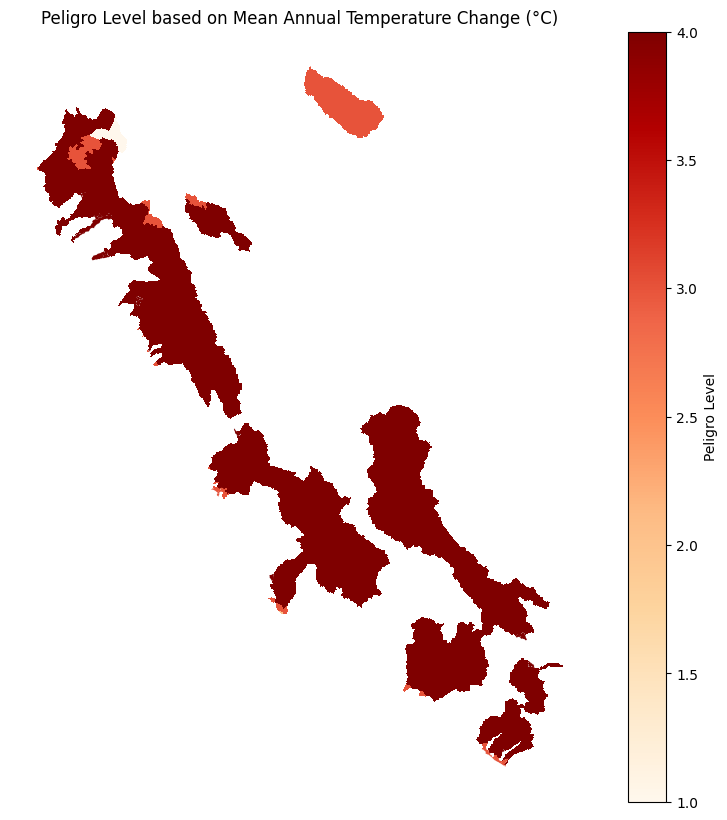

In [9]:
# merge deltas with subbasins to plot for QC
deltas_gdf = subbasins_gdf.merge(deltas, left_index=True, right_on='comid', how='left')

fig, ax = plt.subplots(figsize=(10, 10))

# plot subbasins
subbasins_gdf.plot(ax=ax,color='lightgrey',edgecolor='white',linewidth=0.3)

# plot delta hazard values
deltas_gdf.plot(column='Hazard_value', ax=ax, legend=True,
                 cmap='OrRd', missing_kwds={"color": "lightgrey"},
                 legend_kwds={'label': "Peligro Level",
                              'orientation': "vertical"})

plt.title('Peligro Level based on Mean Annual Temperature Change (°C)')
plt.axis('off')
plt.show()

In [13]:
# set up dataframe to import results into the database
# Base COMIDs from subbasins
base_comids = subbasins_gdf.index.to_series().reset_index(drop=True)
base_comids.name = 'COMID'

# Scenario table
scenario_df = pd.DataFrame({'ScnID': sorted(set(scenario_ids))})

# Cartesian product: every COMID gets every scenario
base_index = base_comids.to_frame().merge(scenario_df, how='cross')

# Merge future hazard values (ScnID = 2)
hazard_future = deltas[['comid', 'Hazard_value']].rename(columns={'comid': 'COMID'})

hazard_df = base_index.merge(hazard_future,on='COMID',how='left')

# Afill all values of 1 for the baseline scenario and future hazard values that we calculated above for the future scenarios
hazard_df['Value'] = np.where(
    hazard_df['ScnID'] == 1,
    1,  # baseline
    hazard_df['Hazard_value']  # future
)

hazard_df['Value'] = hazard_df['Value'].astype(int)

hazard_df = hazard_df[['ScnID', 'COMID', 'Value']]

In [15]:
# insert data into the sql database
# Connect to SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

rows_to_insert = []

for _, row in hazard_df.iterrows():
    rows_to_insert.append((
        int(row['ScnID']),
        IndID,
        int(row['COMID']),
        float(row['Value'])
    ))


insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""


In [16]:
# check that the expected min and max values in the indicators table match the calculated values
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats_by_scenario = (
    hazard_df
    .groupby('ScnID')['Value']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Value values by scenario ===")
print(value_stats_by_scenario)

df_check = pd.DataFrame(
    rows_to_insert,
    columns=['ScnID', 'IndID', 'COMID', 'Value']
)

duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])

print("\nDuplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 104  Min: 1, Max: 4

=== Value values by scenario ===
   ScnID  min  max  count
0      1    1    1   3655
1      2    1    4   3655

Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [17]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()